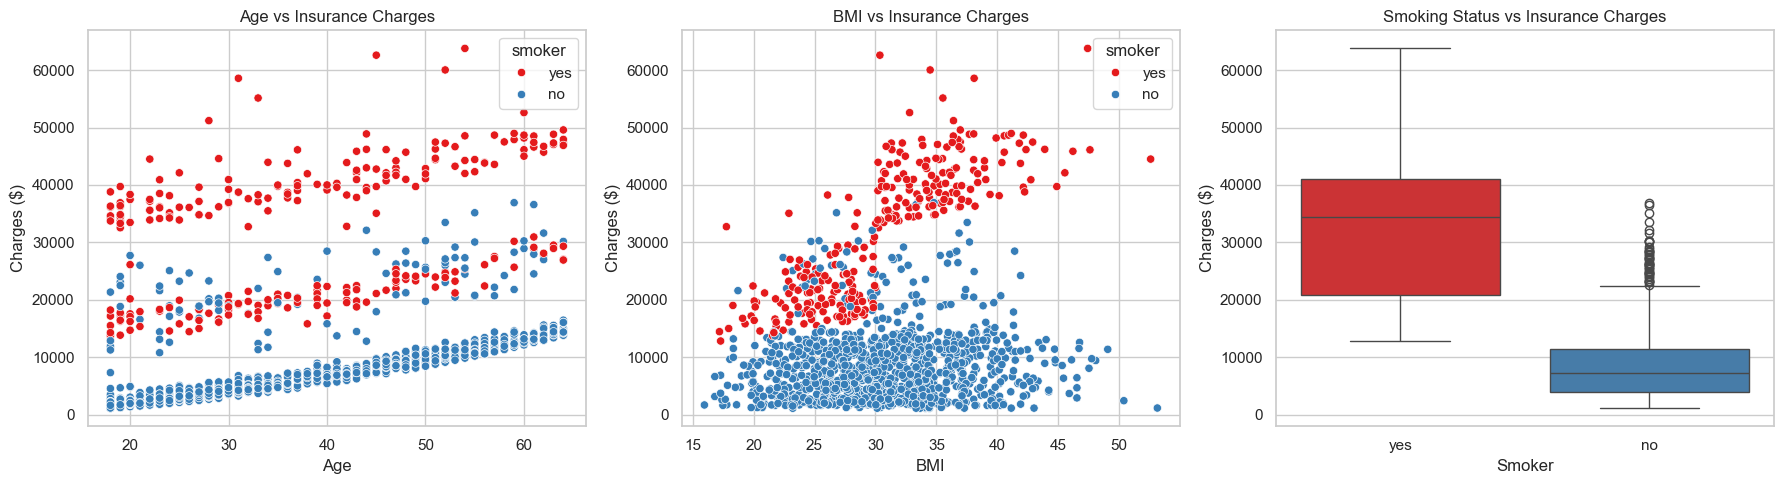

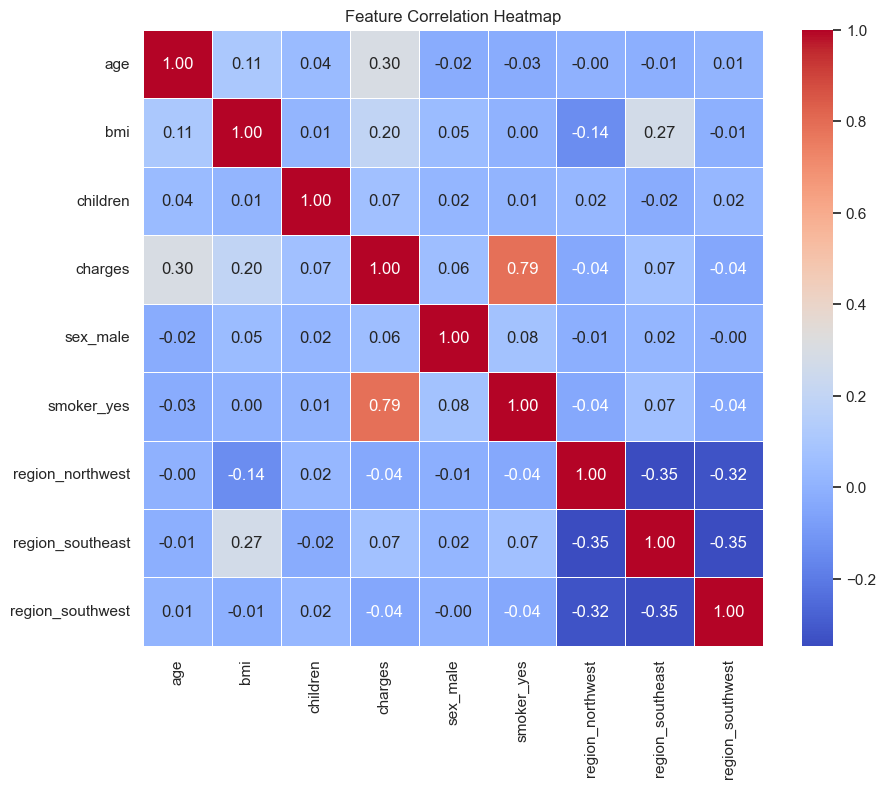

--- Model Evaluation ---
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28
R-squared (Accuracy) Score: 0.7836 (or 78.36%)


In [40]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LOAD DATASET
url = "https://github.com/ShehrozGhouri/Developers-Hub-DataScience-Internship/raw/refs/heads/main/Task%204%20--%20Predicting%20Insurance%20Claim%20Amounts/insurance.csv"
df = pd.read_csv(url)
df.head()

# 2. Visualization: BMI, Age, and Smoking status vs. Charges
plt.figure(figsize=(18, 5))

# Plot A: Age vs Charges (colored by Smoking status)
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='Set1')
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')

# Plot B: BMI vs Charges (colored by Smoking status)
plt.subplot(1, 3, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1')
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')

# Plot C: Smoking Status vs Charges (Boxplot)
# Updated to avoid the seaborn FutureWarning!
plt.subplot(1, 3, 3)
sns.boxplot(x='smoker', y='charges', data=df, hue='smoker', palette='Set1', legend=False)
plt.title('Smoking Status vs Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')

plt.tight_layout()
plt.show() 

# 3. Feature Correlation Visualization
# Convert text categories (like sex, smoker, region) into numbers
df_encoded = pd.get_dummies(df, drop_first=True)
corr = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# 4. Train a Linear Regression Model
# Define Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate Model Performance 
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (Accuracy) Score: {r2:.4f} (or {r2 * 100:.2f}%)")

In [41]:
import joblib

# Save the trained model to a file named 'Customer_Chrun_Prediction.pkl'
joblib.dump(model, 'Predicting_Insurance_Claim_Amounts.pkl')

print("Model saved successfully as Predicting_Insurance_Claim_Amounts!")

Model saved successfully as Predicting_Insurance_Claim_Amounts!
